# 01 EDA: Open-Meteo golden dataset の探索

**目的**: NWP予報（previous-runs API）と実測値（ERA5 archive）の構造・品質・分布を確認し、補正が必要な変数と補正の余地を定量的に把握する。

**データソース**:
- Actual（実測）: Open-Meteo ERA5 archive API
- Forecast（NWP予報）: Open-Meteo previous-runs API
- ローカルキャッシュ: `data/golden-dataset/`（`data/01_raw/` と同一構造）

```
data/golden-dataset/open-meteo/
  actual/location=tokyo/year=*/month=*/day=*/raw_actual.json
  forecast/location=tokyo/year=*/month=*/day=*/raw_forecast.json
```

## Setup

In [1]:
import sys
from pathlib import Path

_nb_dir = next(p for p in [Path("."), Path("notebooks")] if (p / "utils.py").exists())
sys.path.insert(0, str(_nb_dir.resolve()))

from utils import load_raw, missing_summary  # noqa: E402

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

## データロード

各 JSON ファイルは Open-Meteo API のレスポンスをそのまま保存したもの。
`hourly` キー以下に各パラメータの時系列配列が格納されている。

In [2]:
actual   = load_raw("actual")
forecast = load_raw("forecast")

print(f"actual  : {actual.shape}  ({actual['datetime'].min().date()} – {actual['datetime'].max().date()})")
print(f"forecast: {forecast.shape}  ({forecast['datetime'].min().date()} – {forecast['datetime'].max().date()})")

actual  : (26304, 42)  (2023-01-01 – 2025-12-31)
forecast: (26304, 59)  (2023-01-01 – 2025-12-31)


## データ概要確認

In [3]:
# actual のカラムと dtype
print("=== actual columns ===")
actual.info(verbose=False, show_counts=True)

=== actual columns ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Columns: 42 entries, datetime to is_day
dtypes: datetime64[ns](1), float64(32), int64(9)
memory usage: 8.4 MB


In [4]:
# forecast のカラムと dtype
print("=== forecast columns ===")
forecast.info(verbose=False, show_counts=True)

=== forecast columns ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26304 entries, 0 to 26303
Columns: 59 entries, datetime to is_day
dtypes: datetime64[ns](1), float64(47), int64(11)
memory usage: 11.8 MB


In [5]:
# 主要変数の統計量
KEY_COLS = ["temperature_2m", "precipitation", "cloud_cover", "cloud_cover_low", "pressure_msl"]

print("--- actual ---")
display(actual[KEY_COLS].describe())

print("--- forecast ---")
display(forecast[KEY_COLS].describe())

--- actual ---


,temperature_2m,precipitation,cloud_cover,cloud_cover_low,pressure_msl
count,26304.000,26304.000,26304.000,26304.000,26304.000
mean,16.755,0.168,58.478,21.037,1013.974
std,9.266,0.806,42.796,34.273,7.045
min,-6.100,0.000,0.000,0.000,988.800
25%,9.075,0.000,8.000,0.000,1008.900
50%,16.800,0.000,78.000,2.000,1013.700
75%,24.600,0.000,100.000,24.000,1019.100
max,39.300,21.800,100.000,100.000,1033.500


--- forecast ---


,temperature_2m,precipitation,cloud_cover,cloud_cover_low,pressure_msl
count,26304.000,26304.000,26304.000,26304.000,26304.000
mean,16.436,0.161,38.450,16.541,1014.298
std,8.890,0.905,33.044,24.341,7.026
min,-4.000,0.000,0.000,0.000,988.600
25%,8.800,0.000,7.000,0.000,1009.300
50%,16.500,0.000,32.000,5.000,1014.100
75%,24.200,0.000,67.000,24.000,1019.400
max,36.800,34.500,100.000,100.000,1034.100


In [6]:
# 降水量の非ゼロ分布確認
precip = actual["precipitation"]
print(f"全行数  : {len(precip):,}")
print(f"ゼロ    : {(precip == 0).sum():,}  ({(precip == 0).mean():.1%})")
print(f"非ゼロ  : {(precip > 0).sum():,}  ({(precip > 0).mean():.1%})")
print()
print("非ゼロの上位 30 件:")
display(
    actual[precip > 0][["datetime", "precipitation"]]
    .nlargest(30, "precipitation")
    .reset_index(drop=True)
)

全行数  : 26,304
ゼロ    : 22,090  (84.0%)
非ゼロ  : 4,214  (16.0%)

非ゼロの上位 30 件:


,datetime,precipitation
0,2025-09-05 10:00:00,21.800
1,2025-05-02 20:00:00,20.900
2,2023-08-15 03:00:00,20.600
3,2024-11-02 19:00:00,16.300
4,2025-05-02 19:00:00,16.300
5,2023-06-03 03:00:00,16.000
6,2024-06-28 14:00:00,15.500
7,2025-05-02 18:00:00,15.300
8,2024-07-21 01:00:00,15.000
9,2024-11-27 02:00:00,14.900


## 欠損値の確認

ERA5 と previous-runs どちらも、hourly データとして完全に埋まっているはず。
欠損があれば、その日のAPIレスポンスが不完全だった可能性がある。

In [7]:
missing_summary(actual, "actual")
missing_summary(forecast, "forecast")

actual: 欠損なし
forecast: 欠損なし


In [8]:
# 重複タイムスタンプの確認（日付境界に発生しやすい）
print("actual  重複:", actual.duplicated(subset=["datetime"]).sum())
print("forecast重複:", forecast.duplicated(subset=["datetime"]).sum())

# 重複があれば最初のものを残す
actual   = actual.drop_duplicates(subset=["datetime"]).reset_index(drop=True)
forecast = forecast.drop_duplicates(subset=["datetime"]).reset_index(drop=True)

actual  重複: 0
forecast重複: 0


## 時系列プロット: 実測値の基本確認

- 季節性が自然か
- データの途切れがないか
- 明らかな異常値がないか

> **Note — `pressure_msl` について**
> 補正対象（temp / precip / cloud / cloud_low）ではなく、特徴量として利用する変数。
> 後続の `02_error_analysis` で気圧傾向（`pressure_trend_{3,6,12}h`）が補正誤差と相関することを確認し、
> 特徴量グループ E「大気パターン」に採用する。

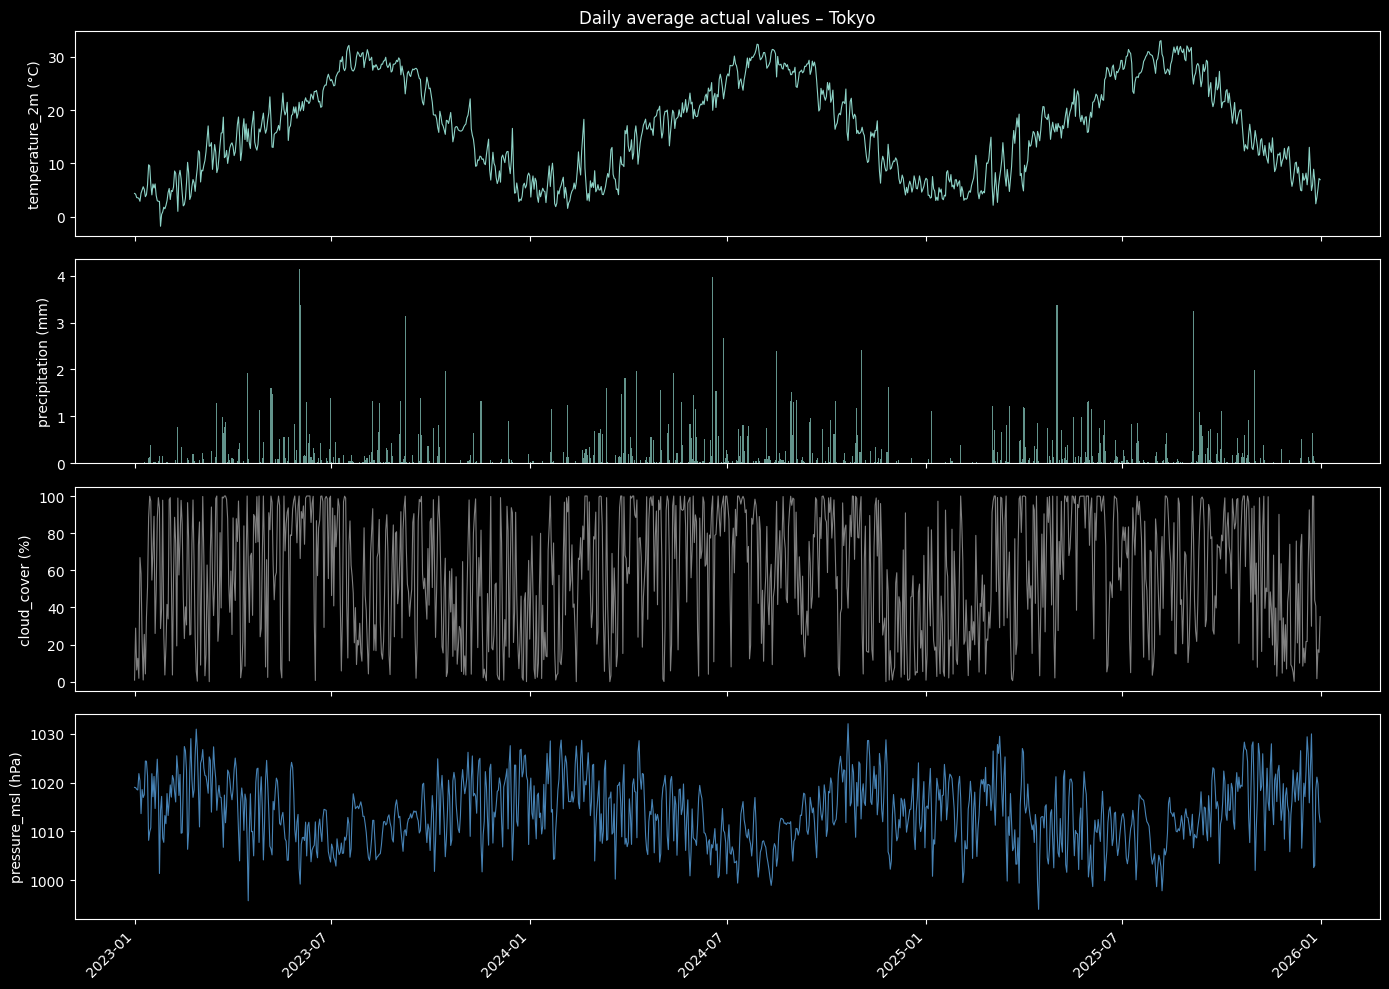

In [9]:
daily = actual.set_index("datetime").resample("D").mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily["datetime"], daily["temperature_2m"], lw=0.8)
axes[0].set_ylabel("temperature_2m (°C)")
axes[0].set_title("Daily average actual values – Tokyo")

axes[1].bar(daily["datetime"], daily["precipitation"], width=1, alpha=0.7)
axes[1].set_ylabel("precipitation (mm)")

axes[2].plot(daily["datetime"], daily["cloud_cover"], lw=0.8, color="gray")
axes[2].set_ylabel("cloud_cover (%)")

axes[3].plot(daily["datetime"], daily["pressure_msl"], lw=0.8, color="steelblue")
axes[3].set_ylabel("pressure_msl (hPa)")
axes[3].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(axes[3].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 実測値 vs 予報値の比較

NWP予報は数値計算モデルの出力であり、実測との誤差（バイアス）が生じる。
以下では 4 つの主要変数について比較する。

In [10]:
# actual と forecast を datetime で結合（inner join）
merged = pd.merge(
    actual.rename(columns={c: f"actual_{c}" for c in actual.columns if c != "datetime"}),
    forecast.rename(columns={c: f"forecast_{c}" for c in forecast.columns if c != "datetime"}),
    on="datetime",
    how="inner",
)
print(f"merged: {len(merged):,} rows  ({merged['datetime'].min().date()} – {merged['datetime'].max().date()})")

merged: 26,304 rows  (2023-01-01 – 2025-12-31)


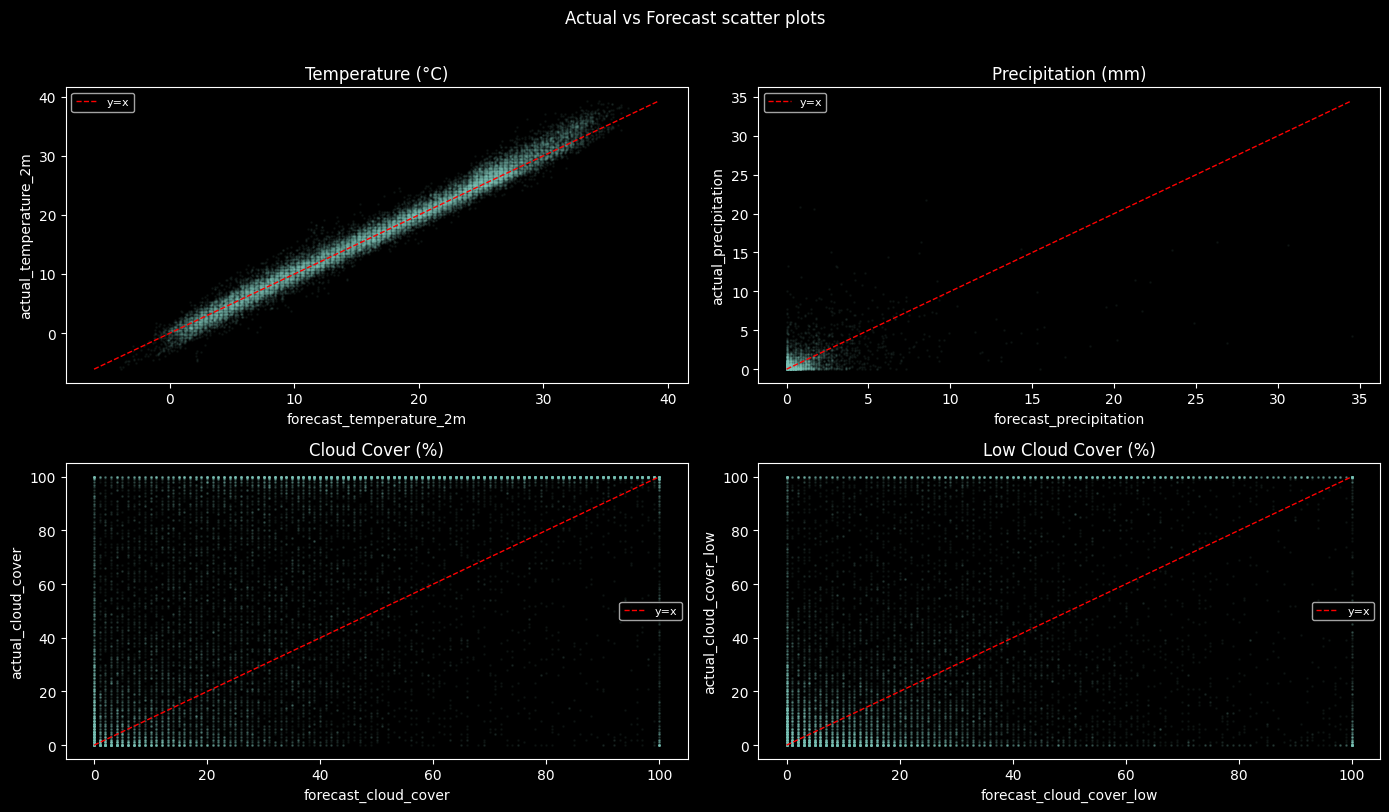

In [11]:
COMPARE_VARS = [
    ("temperature_2m",  "temperature_2m",  "Temperature (°C)"),
    ("precipitation",   "precipitation",   "Precipitation (mm)"),
    ("cloud_cover",     "cloud_cover",     "Cloud Cover (%)"),
    ("cloud_cover_low", "cloud_cover_low", "Low Cloud Cover (%)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (a_col, f_col, label) in zip(axes.flat, COMPARE_VARS):
    a = f"actual_{a_col}"
    f = f"forecast_{f_col}"
    if a not in merged.columns or f not in merged.columns:
        ax.set_visible(False)
        continue
    valid = merged[[a, f]].dropna()
    ax.scatter(valid[f], valid[a], alpha=0.05, s=1)
    lim = [min(valid[f].min(), valid[a].min()), max(valid[f].max(), valid[a].max())]
    ax.plot(lim, lim, "r--", lw=1, label="y=x")
    ax.set_xlabel(f"forecast_{f_col}")
    ax.set_ylabel(f"actual_{a_col}")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle("Actual vs Forecast scatter plots", y=1.01)
plt.tight_layout()
plt.show()

## 予報誤差の定量評価

MAE・RMSE・バイアス（系統誤差）を確認し、補正優先順位を決める。

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

summary_rows = []
for a_col, f_col, label in COMPARE_VARS:
    a = f"actual_{a_col}"
    f = f"forecast_{f_col}"
    if a not in merged.columns or f not in merged.columns:
        continue
    valid = merged[[a, f]].dropna()
    error = valid[a] - valid[f]
    mean_actual = valid[a].mean()

    # 評価指標の計算
    mae = mean_absolute_error(valid[a], valid[f])
    rmse = np.sqrt(mean_squared_error(valid[a], valid[f]))
    bias = error.mean()
    summary_rows.append({
        "variable": label,
        "n": len(valid),
        "MAE":  mean_absolute_error(valid[a], valid[f]),
        "RMSE": np.sqrt(mean_squared_error(valid[a], valid[f])),
        "bias": error.mean(),
        "std":  error.std(),
        # 単位が異なる変数同士を比較するための相対指標（平均値に対するMAEの割合）
        # この値の単位は%で大きいなら大外れ値の警戒が必要
        "MAE_pct": (mae / mean_actual * 100) if mean_actual != 0 else np.nan,
        # biasの影響度合い（1に近いほど単純補正で改善しやすい）
        "bias_ratio": abs(bias) / mae if mae != 0 else 0
    })

summary_df = pd.DataFrame(summary_rows).set_index("variable")
display(summary_df.round(3))

,n,MAE,RMSE,bias,std,MAE_pct,bias_ratio
variable,,,,,,,
Temperature (°C),26304,1.006,1.331,0.319,1.293,6.004,0.317
Precipitation (mm),26304,0.152,0.762,0.007,0.762,90.500,0.044
Cloud Cover (%),26304,26.633,36.690,20.028,30.742,45.544,0.752
Low Cloud Cover (%),26304,16.295,28.740,4.496,28.387,77.460,0.276


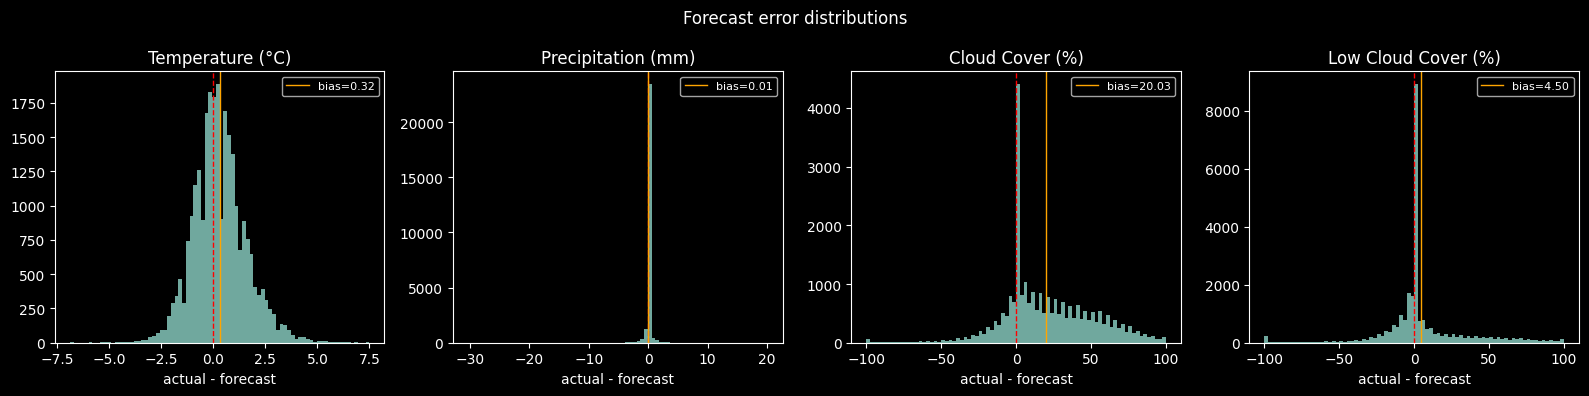

In [13]:
# 誤差分布のヒストグラム
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (a_col, f_col, label) in zip(axes, COMPARE_VARS):
    a = f"actual_{a_col}"
    f = f"forecast_{f_col}"
    if a not in merged.columns or f not in merged.columns:
        ax.set_visible(False)
        continue
    error = (merged[a] - merged[f]).dropna()
    ax.hist(error, bins=80, edgecolor="none", alpha=0.8)
    ax.axvline(0, color="red", lw=1, linestyle="--")
    ax.axvline(error.mean(), color="orange", lw=1, label=f"bias={error.mean():.2f}")
    ax.set_title(label)
    ax.set_xlabel("actual - forecast")
    ax.legend(fontsize=8)

plt.suptitle("Forecast error distributions")
plt.tight_layout()
plt.show()

## 季節性の確認

月別の実測平均と予報平均を比較する。系統的な季節バイアスがあるかを確認。

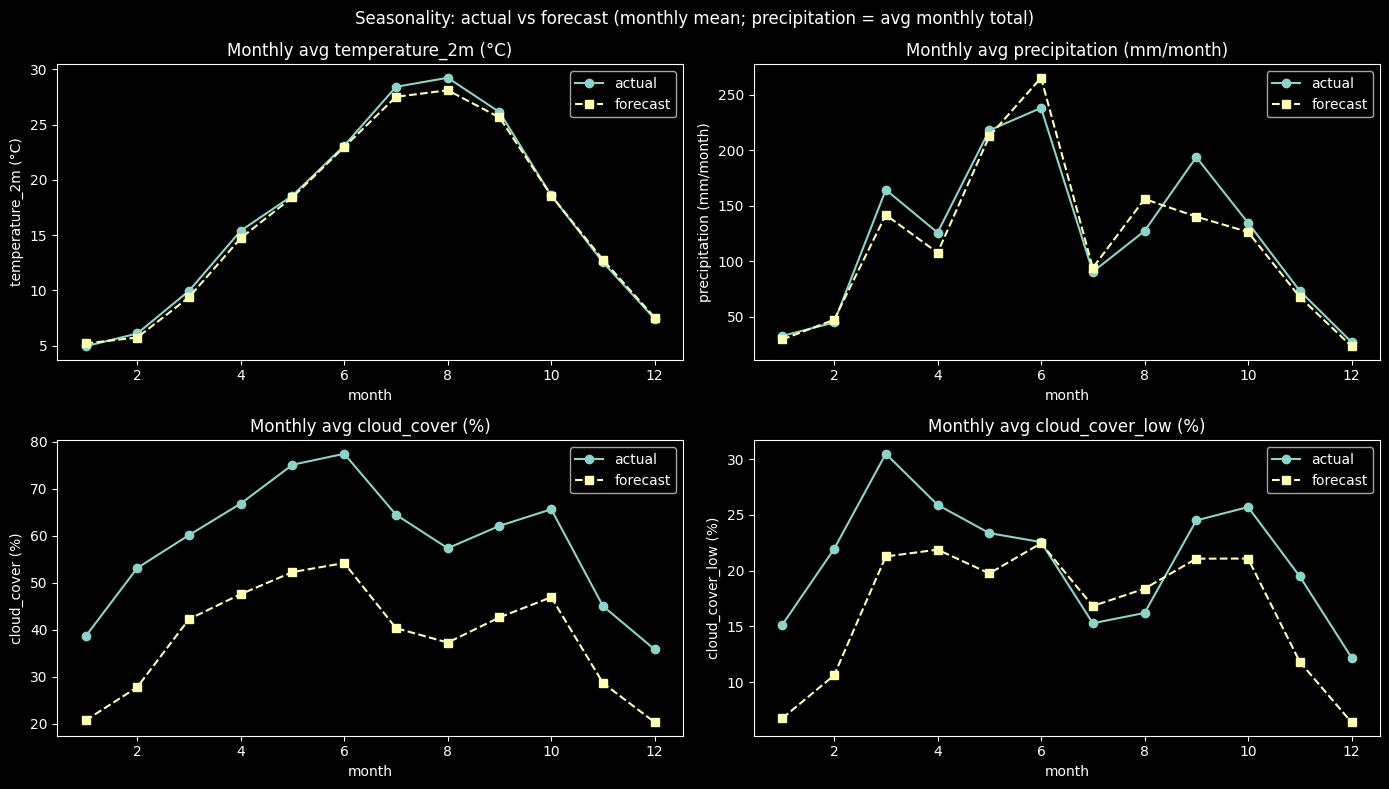

In [14]:
merged["month"] = merged["datetime"].dt.month
merged["year"]  = merged["datetime"].dt.year

# 降水量は年×月で合計してから月平均（平均月間降水量）、他は月平均
precip_monthly = (
    merged.groupby(["year", "month"])[["actual_precipitation", "forecast_precipitation"]]
    .sum()
    .groupby("month")
    .mean()
    .rename(columns={"actual_precipitation": "actual_precip", "forecast_precipitation": "forecast_precip"})
)
monthly = merged.groupby("month").agg(
    actual_temp=("actual_temperature_2m", "mean"),
    forecast_temp=("forecast_temperature_2m", "mean"),
    actual_cloud=("actual_cloud_cover", "mean"),
    forecast_cloud=("forecast_cloud_cover", "mean"),
    actual_cloud_low=("actual_cloud_cover_low", "mean"),
    forecast_cloud_low=("forecast_cloud_cover_low", "mean"),
).join(precip_monthly)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_cfg = [
    ("actual_temp",      "forecast_temp",      "temperature_2m (°C)",        axes[0, 0]),
    ("actual_precip",    "forecast_precip",    "precipitation (mm/month)",    axes[0, 1]),
    ("actual_cloud",     "forecast_cloud",     "cloud_cover (%)",             axes[1, 0]),
    ("actual_cloud_low", "forecast_cloud_low", "cloud_cover_low (%)",         axes[1, 1]),
]

for a_col, f_col, ylabel, ax in plot_cfg:
    ax.plot(monthly.index, monthly[a_col], "o-", label="actual")
    ax.plot(monthly.index, monthly[f_col], "s--", label="forecast")
    ax.set_xlabel("month")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Monthly avg {ylabel}")
    ax.legend()

plt.suptitle("Seasonality: actual vs forecast (monthly mean; precipitation = avg monthly total)")
plt.tight_layout()
plt.show()

## 時間帯別の予報精度

日中・夜間でNWPの精度が異なるかを確認。気温の日変化は特に重要。

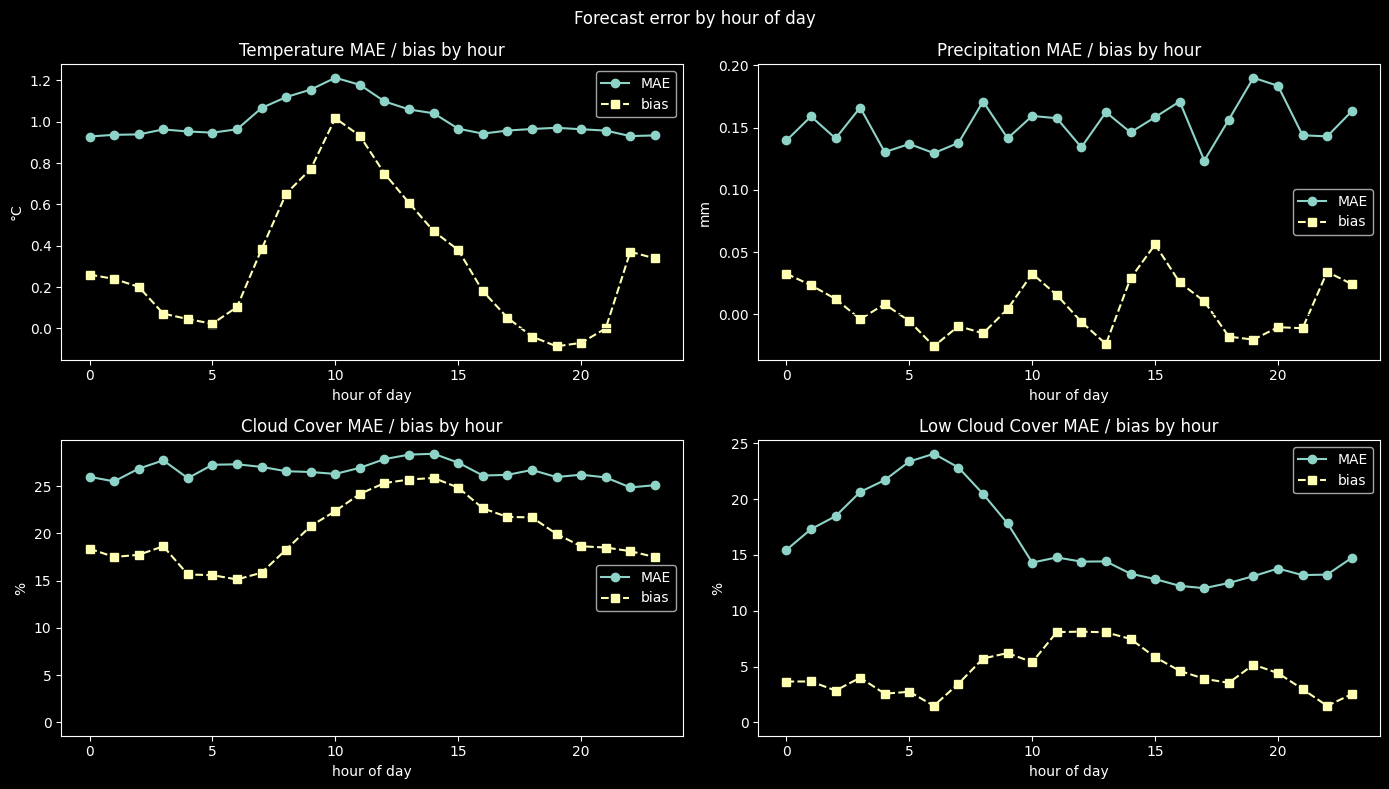

In [15]:
merged["hour"] = merged["datetime"].dt.hour

hourly_err = merged.groupby("hour").apply(
    lambda g: pd.Series({
        "temp_mae":       (g["actual_temperature_2m"]  - g["forecast_temperature_2m"]).abs().mean(),
        "temp_bias":      (g["actual_temperature_2m"]  - g["forecast_temperature_2m"]).mean(),
        "precip_mae":     (g["actual_precipitation"]   - g["forecast_precipitation"]).abs().mean(),
        "precip_bias":    (g["actual_precipitation"]   - g["forecast_precipitation"]).mean(),
        "cloud_mae":      (g["actual_cloud_cover"]     - g["forecast_cloud_cover"]).abs().mean(),
        "cloud_bias":     (g["actual_cloud_cover"]     - g["forecast_cloud_cover"]).mean(),
        "cloud_low_mae":  (g["actual_cloud_cover_low"] - g["forecast_cloud_cover_low"]).abs().mean(),
        "cloud_low_bias": (g["actual_cloud_cover_low"] - g["forecast_cloud_cover_low"]).mean(),
    }),
    include_groups=False,
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_cfg = [
    ("temp_mae",      "temp_bias",      "°C", "Temperature",     axes[0, 0]),
    ("precip_mae",    "precip_bias",    "mm", "Precipitation",   axes[0, 1]),
    ("cloud_mae",     "cloud_bias",     "%",  "Cloud Cover",     axes[1, 0]),
    ("cloud_low_mae", "cloud_low_bias", "%",  "Low Cloud Cover", axes[1, 1]),
]

for mae_col, bias_col, unit, title, ax in plot_cfg:
    ax.plot(hourly_err["hour"], hourly_err[mae_col],  "o-",  label="MAE")
    ax.plot(hourly_err["hour"], hourly_err[bias_col], "s--", label="bias")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("hour of day")
    ax.set_ylabel(unit)
    ax.set_title(f"{title} MAE / bias by hour")
    ax.legend()

plt.suptitle("Forecast error by hour of day")
plt.tight_layout()
plt.show()

## 補正対象変数の決定

EDA の結果から、以下の 4 変数を補正対象とする。

| ターゲット | 単位 | 選定理由 |
|-|-|-|
| `temp_error` = actual_temperature_2m − forecast_temperature_2m | ℃ | 日変化バイアスが顕著。最も利用頻度の高い変数 |
| `precip_error` = actual_precipitation − forecast_precipitation | mm | 降水有無の誤予報が多い。実用上重要 |
| `cloud_error` = actual_cloud_cover − forecast_cloud_cover | % | 雲量誤差は放射・気温誤差と連動 |
| `cloud_low_error` = actual_cloud_cover_low − forecast_cloud_cover_low | % | 下層雲は体感・視程に直結 |

**補正しない変数**: 土壌温度・蒸発散・紫外線など、予報精度が高く用途が限定的なものは対象外。

In [16]:
# 補正対象 4 変数の誤差をまとめて確認
ERROR_MAP = {
    "temp_error":      ("actual_temperature_2m",  "forecast_temperature_2m"),
    "precip_error":    ("actual_precipitation",    "forecast_precipitation"),
    "cloud_error":     ("actual_cloud_cover",      "forecast_cloud_cover"),
    "cloud_low_error": ("actual_cloud_cover_low",  "forecast_cloud_cover_low"),
}

for err_name, (a_col, f_col) in ERROR_MAP.items():
    if a_col in merged.columns and f_col in merged.columns:
        merged[err_name] = merged[a_col] - merged[f_col]

error_cols = list(ERROR_MAP.keys())
display(merged[error_cols].describe().round(3))

,temp_error,precip_error,cloud_error,cloud_low_error
count,26304.000,26304.000,26304.000,26304.000
mean,0.319,0.007,20.028,4.496
std,1.293,0.762,30.742,28.387
min,-6.900,-30.300,-100.000,-100.000
25%,-0.500,0.000,0.000,-4.000
50%,0.200,0.000,14.000,0.000
75%,1.100,0.000,41.000,8.000
max,7.500,20.100,100.000,100.000


## まとめ

- **データ品質**: ERA5・previous-runs ともに欠損は実質ゼロ。日付境界の重複は除去済み。
- **誤差の規模**: 気温は MAE ≈ 1℃、雲量は MAE ≈ 26%、降水は MAE ≈ 0.15mm（但し極端な降水時は大きい）
- **時間帯依存性**: 気温誤差は日中（6–16 時）に大きい傾向 → 時刻特徴量が有効
- **季節依存性**: 夏季（梅雨期）に雲量誤差が拡大 → 月・季節特徴量が有効
- **補正対象**: `temp_error`, `precip_error`, `cloud_error`, `cloud_low_error` の 4 つ

→ 次の notebook `02_error_analysis.ipynb` で誤差の自己相関・パターンを詳細に分析する。